In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [4]:
df.columns = ['X','Y','class']

In [5]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [6]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [8]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                30        
                                                                 
 dense_1 (Dense)             (None, 10)                110       
                                                                 
 dense_2 (Dense)             (None, 10)                110       
                                                                 
 dense_3 (Dense)             (None, 10)                110       
                                                                 
 dense_4 (Dense)             (None, 1)                 11        
                                                                 
Total params: 371
Trainable params: 371
Non-trainable params: 0
_________________________________________________________________


In [9]:
model.get_weights()

[array([[ 0.61455506, -0.392365  ,  1.5646533 , -0.98251295,  0.9313568 ,
          1.9413431 , -0.8292406 , -0.45762622,  0.7322469 ,  0.5717309 ],
        [ 0.23502861, -0.14535989,  0.2897525 ,  0.45769662,  2.0701773 ,
         -0.4028164 , -1.4621513 ,  0.9101261 , -0.1619408 ,  0.79288065]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-4.1467974e-01, -3.9556900e-01, -9.2389369e-01, -1.0189672e-01,
          7.1860826e-01,  3.0770215e-01,  8.7588906e-01, -7.0009500e-01,
          6.2798989e-01, -5.0251323e-01],
        [ 4.1841042e-01, -1.0813033e-01,  2.4366237e-02,  7.2834069e-01,
         -9.7594440e-02, -5.0532568e-01,  2.8469829e-02, -2.7191601e-04,
          3.8252759e-01, -1.1052104e-01],
        [-6.5782982e-01,  2.9304221e-01,  1.7324096e-01,  3.5548910e-01,
         -8.0270731e-01, -1.8378776e-02, -1.3229457e-01,  1.4269468e-01,
         -3.9860360e-02, -8.1752509e-01],
        [-7.8450334e-01, -3.7712586e-01, -9.62965

In [10]:
initial_weights = model.get_weights()

In [11]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [12]:
model.set_weights(initial_weights)

In [13]:
model.get_weights()

[array([[-0.10348428,  0.39212897, -0.83396155,  0.724751  ,  0.40236202,
          0.82461274, -0.5485814 , -0.9585221 ,  0.11607666,  0.7313714 ],
        [ 0.13972336, -0.26891682, -0.98644066,  0.7811501 , -0.21731097,
         -0.06966053,  0.48157042, -0.7686099 ,  0.00582779,  0.6961952 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-2.07905516e-01, -1.24701969e-01, -1.68526784e-01,
         -2.56064013e-02,  6.43595397e-01,  4.08507437e-01,
         -1.91853964e-04,  4.52459514e-01, -7.19516054e-02,
          2.14235649e-01],
        [ 1.91390783e-01,  2.11015254e-01, -6.54039145e-01,
         -1.64316222e-01,  3.97086218e-02, -5.54605246e-01,
         -2.00274587e-01,  4.14864272e-01,  1.83927923e-01,
         -3.72198433e-01],
        [ 3.13846439e-01,  4.59816456e-01, -1.99915558e-01,
         -6.62253737e-01,  2.26265773e-01, -5.54184169e-02,
         -3.45571101e-01,  4.60432410e-01,  2.56939381e-01,
          8.2491263

In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 4s 164ms/step - loss: 0.6956 - accuracy: 0.2278 - val_loss: 0.6929 - val_accuracy: 0.4000
Epoch 2/100
3/3 [==============================] - 0s 25ms/step - loss: 0.6943 - accuracy: 0.3544 - val_loss: 0.6919 - val_accuracy: 0.7000
Epoch 3/100
3/3 [==============================] - 0s 27ms/step - loss: 0.6932 - accuracy: 0.5696 - val_loss: 0.6909 - val_accuracy: 0.6500
Epoch 4/100
3/3 [==============================] - 0s 28ms/step - loss: 0.6921 - accuracy: 0.5696 - val_loss: 0.6903 - val_accuracy: 0.6500
Epoch 5/100
3/3 [==============================] - 0s 34ms/step - loss: 0.6914 - accuracy: 0.5696 - val_loss: 0.6900 - val_accuracy: 0.6500
Epoch 6/100
3/3 [==============================] - 0s 36ms/step - loss: 0.6911 - accuracy: 0.5696 - val_loss: 0.6899 - val_accuracy: 0.7000
Epoch 7/100
3/3 [==============================] - 0s 35ms/step - loss: 0.6908 - accuracy: 0.5696 - val_loss: 0.6897 - val_accuracy: 0.7000
Epoch 8/100
3/3 [==

In [15]:
model.get_weights()

[array([[-0.2596098 ,  0.549559  , -0.6313343 ,  0.62516224,  0.51176894,
          0.98038733, -0.74298966, -1.2398076 ,  0.25379473,  0.8005102 ],
        [ 0.3037488 , -0.5859733 , -1.259217  ,  1.0600798 , -0.44005552,
         -0.36447456,  0.24469605, -0.7774296 , -0.3302897 ,  0.9207155 ]],
       dtype=float32),
 array([ 0.11114929, -0.03574712,  0.34639925,  0.08011241,  0.01937656,
        -0.0785987 , -0.21411012, -0.02642394,  0.07391661,  0.17585206],
       dtype=float32),
 array([[-2.6910844e-01,  5.8945210e-04, -1.8015812e-01, -1.4195333e-01,
          5.1939785e-01,  6.0634530e-01,  2.6591611e-01,  5.0734538e-01,
          2.1000917e-01,  1.6511858e-01],
        [ 3.7714809e-01,  3.0965066e-01, -6.5403914e-01, -1.2702635e-02,
          2.8323397e-01, -7.0786500e-01, -3.0315289e-01,  6.4483857e-01,
          3.9292886e-03, -3.8425261e-01],
        [ 3.7614724e-01,  5.3719383e-01, -1.9991556e-01, -7.6932317e-01,
          6.1304796e-01, -1.6025005e-01, -5.4058230e-01,  4

9600/9600 [==============================] - 23s 2ms/step


<Axes: >

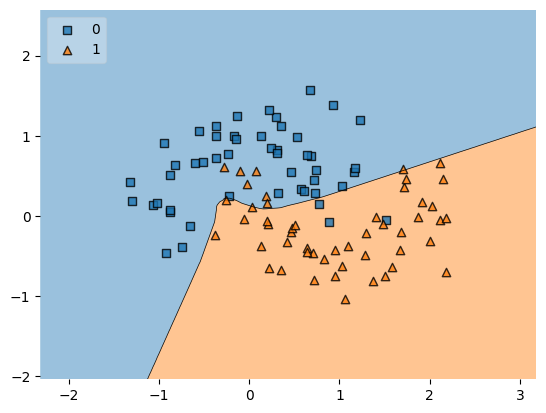

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [17]:
(np.random.randn(10,10)*0.01).min()

-0.024335191610131077

In [18]:
(np.random.randn(10,10)*0.01).max()

0.02391447479387492